In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df_bm = pd.read_csv("Data/big_mart_sales.csv")
df_bm.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df_bm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
df_bm.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [7]:
median_sales = df_bm["Item_Outlet_Sales"].median()

df_bm["Sales_Class"] = (
    df_bm["Item_Outlet_Sales"] >= median_sales
).astype(int)

print("Median Sales:", median_sales)

print(
    df_bm["Sales_Class"].value_counts()
)

Median Sales: 1794.331
Sales_Class
1    4266
0    4257
Name: count, dtype: int64


In [8]:
X_bm = df_bm.drop(
    columns=[
        "Item_Outlet_Sales",
        "Sales_Class"
    ]
)

y_bm = df_bm["Sales_Class"]

In [9]:
print(X_bm.dtypes)

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
dtype: object


In [10]:
numeric_columns = X_bm.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X_bm.select_dtypes(
    include=["object"]
).columns

print("Numerical:")
print(list(numeric_columns))

print("\nCategorical:")
print(list(categorical_columns))

Numerical:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

Categorical:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [11]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_columns
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_columns
    )
])

In [12]:
X_bm_processed = preprocessor.fit_transform(X_bm)

print(
    "Processed Shape:",
    X_bm_processed.shape
)

Processed Shape: (8523, 1604)


In [13]:
X_train_bm, X_test_bm, y_train_bm, y_test_bm = train_test_split(
    X_bm_processed,
    y_bm,
    test_size=0.20,
    random_state=42,
    stratify=y_bm
)

print("Training:", X_train_bm.shape)
print("Testing:", X_test_bm.shape)

Training: (6818, 1604)
Testing: (1705, 1604)


In [14]:
linear_svm_bm = SVC(
    kernel="linear",
    C=1.0
)

linear_svm_bm.fit(
    X_train_bm,
    y_train_bm
)

SVC(kernel='linear')

In [15]:
y_pred_linear_bm = linear_svm_bm.predict(
    X_test_bm
)

In [16]:
accuracy_linear_bm = accuracy_score(
    y_test_bm,
    y_pred_linear_bm
)

print(
    "Linear SVM Accuracy:",
    accuracy_linear_bm * 100,
    "%"
)

Linear SVM Accuracy: 79.82404692082112 %


In [17]:
print(
    classification_report(
        y_test_bm,
        y_pred_linear_bm,
        target_names=[
            "Low Sales",
            "High Sales"
        ]
    )
)

              precision    recall  f1-score   support

   Low Sales       0.81      0.78      0.79       852
  High Sales       0.79      0.82      0.80       853

    accuracy                           0.80      1705
   macro avg       0.80      0.80      0.80      1705
weighted avg       0.80      0.80      0.80      1705



In [18]:
print(
    "Support vectors:",
    linear_svm_bm.n_support_
)

print(
    "Total support vectors:",
    sum(linear_svm_bm.n_support_)
)

Support vectors: [1452 1563]
Total support vectors: 3015


In [19]:
rbf_svm_bm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

rbf_svm_bm.fit(
    X_train_bm,
    y_train_bm
)

SVC()

In [20]:
y_pred_rbf_bm = rbf_svm_bm.predict(
    X_test_bm
)

In [21]:
accuracy_rbf_bm = accuracy_score(
    y_test_bm,
    y_pred_rbf_bm
)

print(
    "Non-Linear RBF SVM Accuracy:",
    accuracy_rbf_bm * 100,
    "%"
)

Non-Linear RBF SVM Accuracy: 82.46334310850439 %


In [22]:
print(
    classification_report(
        y_test_bm,
        y_pred_rbf_bm,
        target_names=[
            "Low Sales",
            "High Sales"
        ]
    )
)

              precision    recall  f1-score   support

   Low Sales       0.85      0.79      0.82       852
  High Sales       0.81      0.86      0.83       853

    accuracy                           0.82      1705
   macro avg       0.83      0.82      0.82      1705
weighted avg       0.83      0.82      0.82      1705



In [23]:
bm_svm_results = pd.DataFrame({

    "Model": [
        "Linear SVM",
        "Non-Linear SVM (RBF)"
    ],

    "Accuracy": [
        accuracy_linear_bm,
        accuracy_rbf_bm
    ]
})

bm_svm_results["Accuracy (%)"] = (
    bm_svm_results["Accuracy"] * 100
)

print(bm_svm_results)

                  Model  Accuracy  Accuracy (%)
0            Linear SVM  0.798240     79.824047
1  Non-Linear SVM (RBF)  0.824633     82.463343


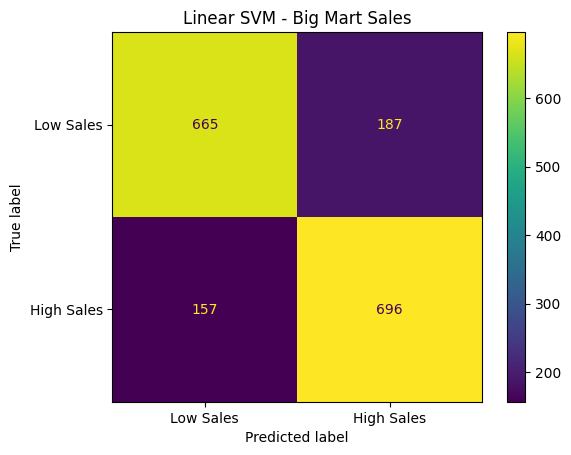

In [24]:
cm_linear_bm = confusion_matrix(
    y_test_bm,
    y_pred_linear_bm
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_linear_bm,
    display_labels=[
        "Low Sales",
        "High Sales"
    ]
)

disp.plot()

plt.title("Linear SVM - Big Mart Sales")

plt.show()

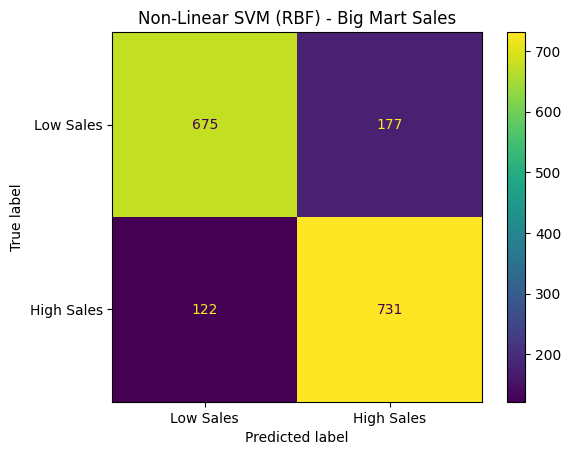

In [25]:
cm_rbf_bm = confusion_matrix(
    y_test_bm,
    y_pred_rbf_bm
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rbf_bm,
    display_labels=[
        "Low Sales",
        "High Sales"
    ]
)

disp.plot()

plt.title(
    "Non-Linear SVM (RBF) - Big Mart Sales"
)

plt.show()

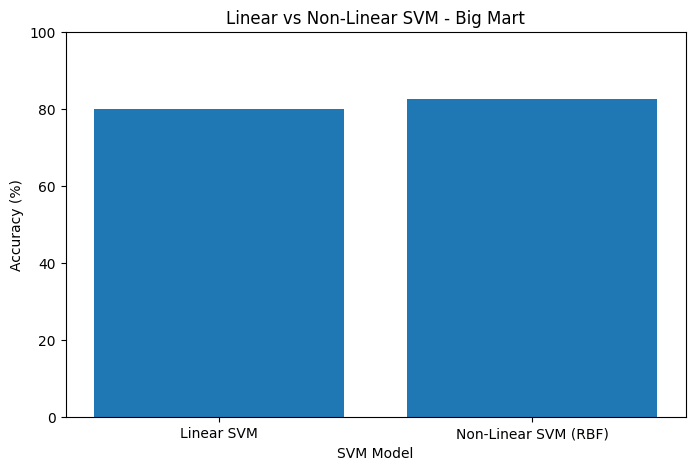

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    bm_svm_results["Model"],
    bm_svm_results["Accuracy (%)"]
)

plt.xlabel("SVM Model")
plt.ylabel("Accuracy (%)")

plt.title(
    "Linear vs Non-Linear SVM - Big Mart"
)

plt.ylim(0, 100)

plt.show()

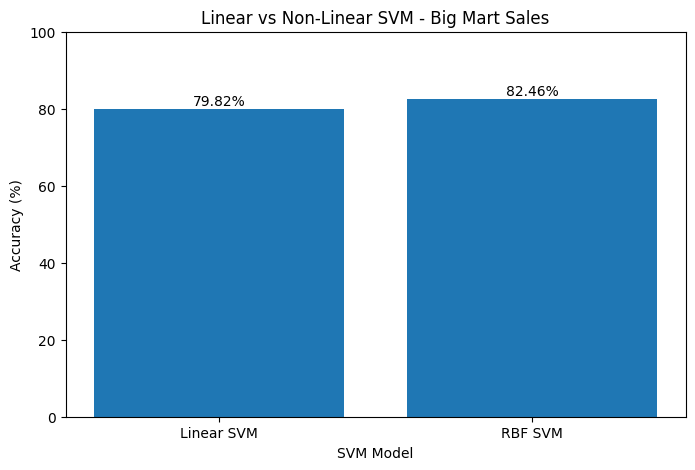

In [38]:
plt.figure(figsize=(8, 5))

models = [
    "Linear SVM",
    "RBF SVM"
]

scores = [
    accuracy_linear_bm * 100,
    accuracy_rbf_bm * 100
]

bars = plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy (%)")
plt.xlabel("SVM Model")
plt.title("Linear vs Non-Linear SVM - Big Mart Sales")
plt.ylim(0, 100)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 1,
        f"{score:.2f}%",
        ha="center"
    )

plt.show()

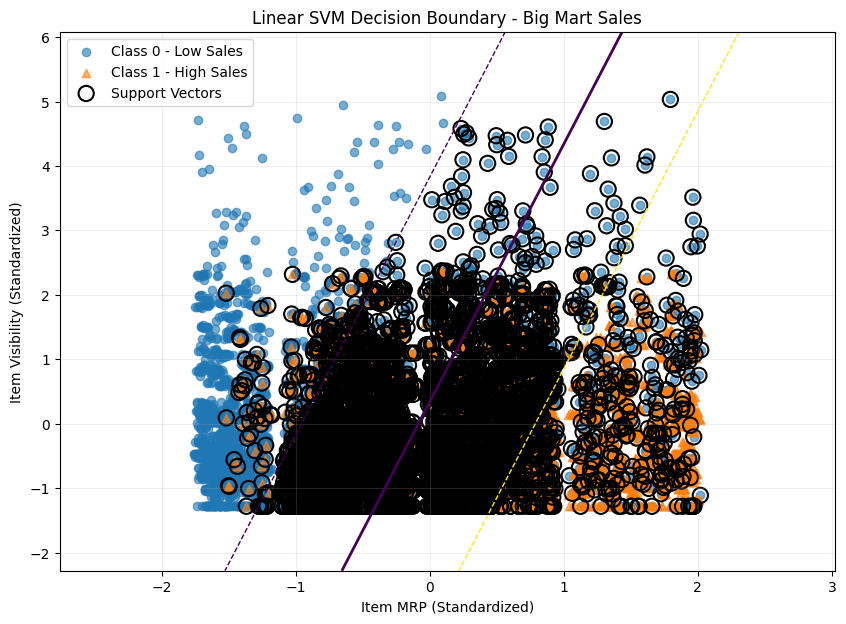

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Select two features
# --------------------------------------------------

features = [
    "Item_MRP",
    "Item_Visibility"
]

X = df_bm[features].copy()
y = df_bm["Sales_Class"]

# Handle missing values
X = X.fillna(X.median())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# 2. Train Linear SVM
# --------------------------------------------------

svm_linear = SVC(
    kernel="linear",
    C=1.0
)

svm_linear.fit(X_scaled, y)

# --------------------------------------------------
# 3. Create mesh grid
# --------------------------------------------------

x_min = X_scaled[:, 0].min() - 1
x_max = X_scaled[:, 0].max() + 1

y_min = X_scaled[:, 1].min() - 1
y_max = X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# --------------------------------------------------
# 4. Calculate decision function
# --------------------------------------------------

Z = svm_linear.decision_function(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# --------------------------------------------------
# 5. Plot data points
# --------------------------------------------------

plt.figure(figsize=(10, 7))

# Class 0
plt.scatter(
    X_scaled[y == 0, 0],
    X_scaled[y == 0, 1],
    marker="o",
    label="Class 0 - Low Sales",
    alpha=0.6
)

# Class 1
plt.scatter(
    X_scaled[y == 1, 0],
    X_scaled[y == 1, 1],
    marker="^",
    label="Class 1 - High Sales",
    alpha=0.6
)

# --------------------------------------------------
# 6. Decision boundary
# --------------------------------------------------

plt.contour(
    xx,
    yy,
    Z,
    levels=[0],
    linewidths=2
)

# --------------------------------------------------
# 7. SVM margins
# --------------------------------------------------

plt.contour(
    xx,
    yy,
    Z,
    levels=[-1, 1],
    linestyles="--",
    linewidths=1
)

# --------------------------------------------------
# 8. Highlight support vectors
# --------------------------------------------------

plt.scatter(
    svm_linear.support_vectors_[:, 0],
    svm_linear.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

# --------------------------------------------------
# 9. Labels
# --------------------------------------------------

plt.xlabel("Item MRP (Standardized)")
plt.ylabel("Item Visibility (Standardized)")

plt.title(
    "Linear SVM Decision Boundary - Big Mart Sales"
)

plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

In [40]:
svm_linear = SVC(
    kernel="linear",
    C=1.0
)

In [41]:
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm_rbf.fit(X_scaled, y)

SVC()

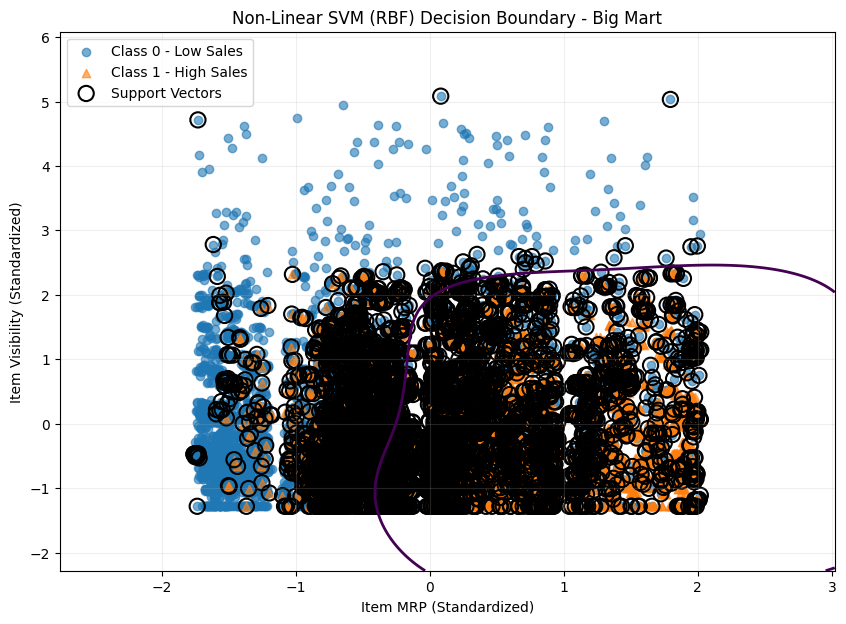

In [42]:
Z = svm_rbf.decision_function(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_scaled[y == 0, 0],
    X_scaled[y == 0, 1],
    marker="o",
    label="Class 0 - Low Sales",
    alpha=0.6
)

plt.scatter(
    X_scaled[y == 1, 0],
    X_scaled[y == 1, 1],
    marker="^",
    label="Class 1 - High Sales",
    alpha=0.6
)

plt.contour(
    xx,
    yy,
    Z,
    levels=[0],
    linewidths=2
)

plt.scatter(
    svm_rbf.support_vectors_[:, 0],
    svm_rbf.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Item MRP (Standardized)")
plt.ylabel("Item Visibility (Standardized)")

plt.title(
    "Non-Linear SVM (RBF) Decision Boundary - Big Mart"
)

plt.legend()
plt.grid(True, alpha=0.2)

plt.show()